In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df=pd.read_csv('../data/healthcare_patient_data.csv')

In [3]:
print(f" the rows are columns of the dataset is {df.shape}")

 the rows are columns of the dataset is (50000, 32)


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   patient_id           50000 non-null  str    
 1   age                  50000 non-null  int64  
 2   gender               50000 non-null  str    
 3   bmi                  44042 non-null  float64
 4   smoking_status       50000 non-null  str    
 5   alcohol_use          22545 non-null  str    
 6   admission_type       50000 non-null  str    
 7   department           50000 non-null  str    
 8   insurance_type       45032 non-null  str    
 9   diabetes             50000 non-null  int64  
 10  hypertension         50000 non-null  int64  
 11  heart_disease        50000 non-null  int64  
 12  copd                 50000 non-null  int64  
 13  ckd                  50000 non-null  int64  
 14  comorbidity_count    50000 non-null  int64  
 15  hemoglobin           47570 non-null  float64
 1

In [5]:
df.describe()

,age,bmi,diabetes,hypertension,heart_disease,copd,ckd,comorbidity_count,hemoglobin,wbc,...,systolic_bp,heart_rate,oxygen_saturation,prev_admissions,prev_surgeries,er_visits_last_year,length_of_stay,treatment_cost,readmission_30day,mortality_risk
count,50000.000000,44042.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,47570.000000,47938.000000,...,50000.000000,50000.000000,47486.000000,50000.000000,45068.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,54.567780,27.561133,0.299100,0.364140,0.220380,0.107580,0.165480,1.156680,12.974276,8.419641,...,132.564820,80.226400,96.187462,1.775520,0.799614,0.731800,6.974464,36452.002720,0.149860,0.057000
std,17.463063,6.388271,0.457868,0.481193,0.414507,0.309852,0.371617,0.971921,2.263663,5.863659,...,20.739454,15.750649,2.399057,1.420679,0.896431,0.863993,2.016857,9656.095935,0.356938,0.231845
min,18.000000,14.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.600000,2.000000,...,80.000000,45.000000,84.400000,0.000000,0.000000,0.000000,3.000000,17428.000000,0.000000,0.000000
25%,42.000000,23.100000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,11.400000,5.700000,...,118.000000,69.000000,94.500000,1.000000,0.000000,0.000000,5.500000,29693.750000,0.000000,0.000000
50%,55.000000,27.500000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,13.000000,7.600000,...,133.000000,80.000000,96.300000,2.000000,1.000000,1.000000,6.700000,34990.000000,0.000000,0.000000
75%,67.000000,31.900000,1.000000,1.000000,0.000000,0.000000,0.000000,2.000000,14.500000,9.600000,...,147.000000,91.000000,98.000000,3.000000,1.000000,1.000000,8.100000,41432.500000,0.000000,0.000000
max,95.000000,54.800000,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000,20.000000,49.981385,...,211.000000,146.000000,100.000000,10.000000,7.000000,6.000000,23.000000,116984.000000,1.000000,1.000000


In [6]:
df.isna().sum().sort_values(ascending=False)

alcohol_use            27455
bmi                     5958
insurance_type          4968
prev_surgeries          4932
glucose                 4464
sodium                  4119
creatinine              3549
platelets               3025
oxygen_saturation       2514
hemoglobin              2430
wbc                     2062
department                 0
gender                     0
smoking_status             0
age                        0
patient_id                 0
comorbidity_count          0
ckd                        0
copd                       0
heart_disease              0
diabetes                   0
hypertension               0
admission_type             0
systolic_bp                0
heart_rate                 0
prev_admissions            0
er_visits_last_year        0
length_of_stay             0
treatment_cost             0
diagnosis_category         0
readmission_30day          0
mortality_risk             0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df['alcohol_use'].value_counts()

alcohol_use
Moderate    17497
Heavy        5048
Name: count, dtype: int64

In [9]:
# numerical and categorical features
numerical=[col for col in df.columns if df[col].dtypes in ['int64','float64'] ]
categorical=df.select_dtypes(include='str').columns.to_list()

In [10]:
df.columns

Index(['patient_id', 'age', 'gender', 'bmi', 'smoking_status', 'alcohol_use',
       'admission_type', 'department', 'insurance_type', 'diabetes',
       'hypertension', 'heart_disease', 'copd', 'ckd', 'comorbidity_count',
       'hemoglobin', 'wbc', 'platelets', 'sodium', 'creatinine', 'glucose',
       'systolic_bp', 'heart_rate', 'oxygen_saturation', 'prev_admissions',
       'prev_surgeries', 'er_visits_last_year', 'length_of_stay',
       'treatment_cost', 'diagnosis_category', 'readmission_30day',
       'mortality_risk'],
      dtype='str')

readmission_30day
0    0.85
1    0.15
Name: proportion, dtype: float64


mortality_risk
0    0.943
1    0.057
Name: proportion, dtype: float64


diagnosis_category
Cardiovascular     0.288
Musculoskeletal    0.240
Neurological       0.199
Oncological        0.152
Respiratory        0.121
Name: proportion, dtype: float64



length_of_stay: mean=7.0, median=6.7, skew=0.87


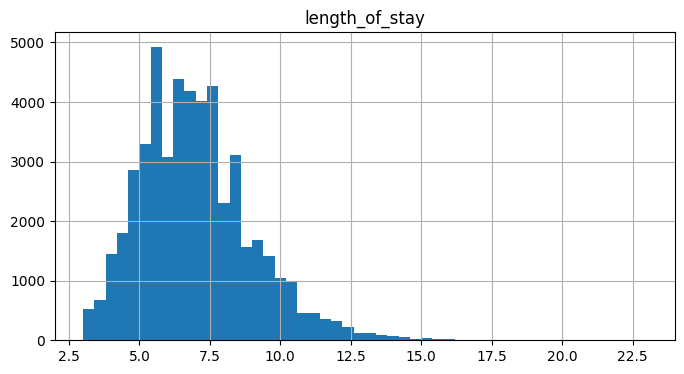


treatment_cost: mean=36452.0, median=34990.0, skew=1.16


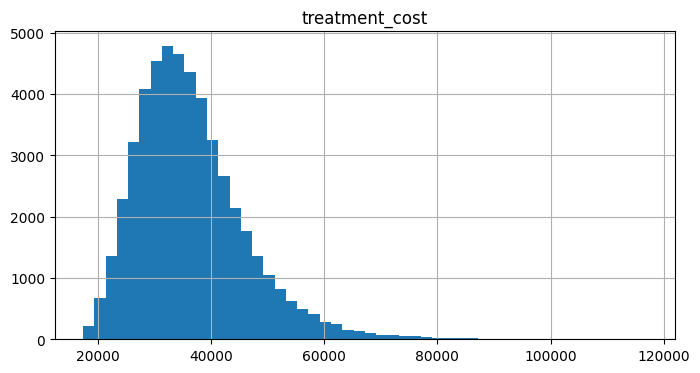

In [11]:
#target inspection
for col in ['readmission_30day', 'mortality_risk','diagnosis_category']:
    print(df[col].value_counts(normalize=True).round(3))
    print(f"\n")
for col in ['length_of_stay', 'treatment_cost']:
    print(f"\n{col}: mean={df[col].mean():.1f}, median={df[col].median():.1f}, skew={df[col].skew():.2f}")
    df[col].hist(bins=50, figsize=(8,4))
    plt.title(col)
    plt.show()

Observations from the target analysis
1) As there is imbalance in target , we use balance techniques to make it balanced from both unique classes for readmission_30day 
2) But for mortality_risk , there are no minority class samples to train , we need stronger technique like SMOTE to fix this 
3) for multiclass classification diagnosis_category , the classes is balanced , so it is managable
4) for both regression targets length_of_stay and treatment_cost the skewness is nearing 1 and exceeded one for treatment_cost , so we log transform them to reduce impact on other features

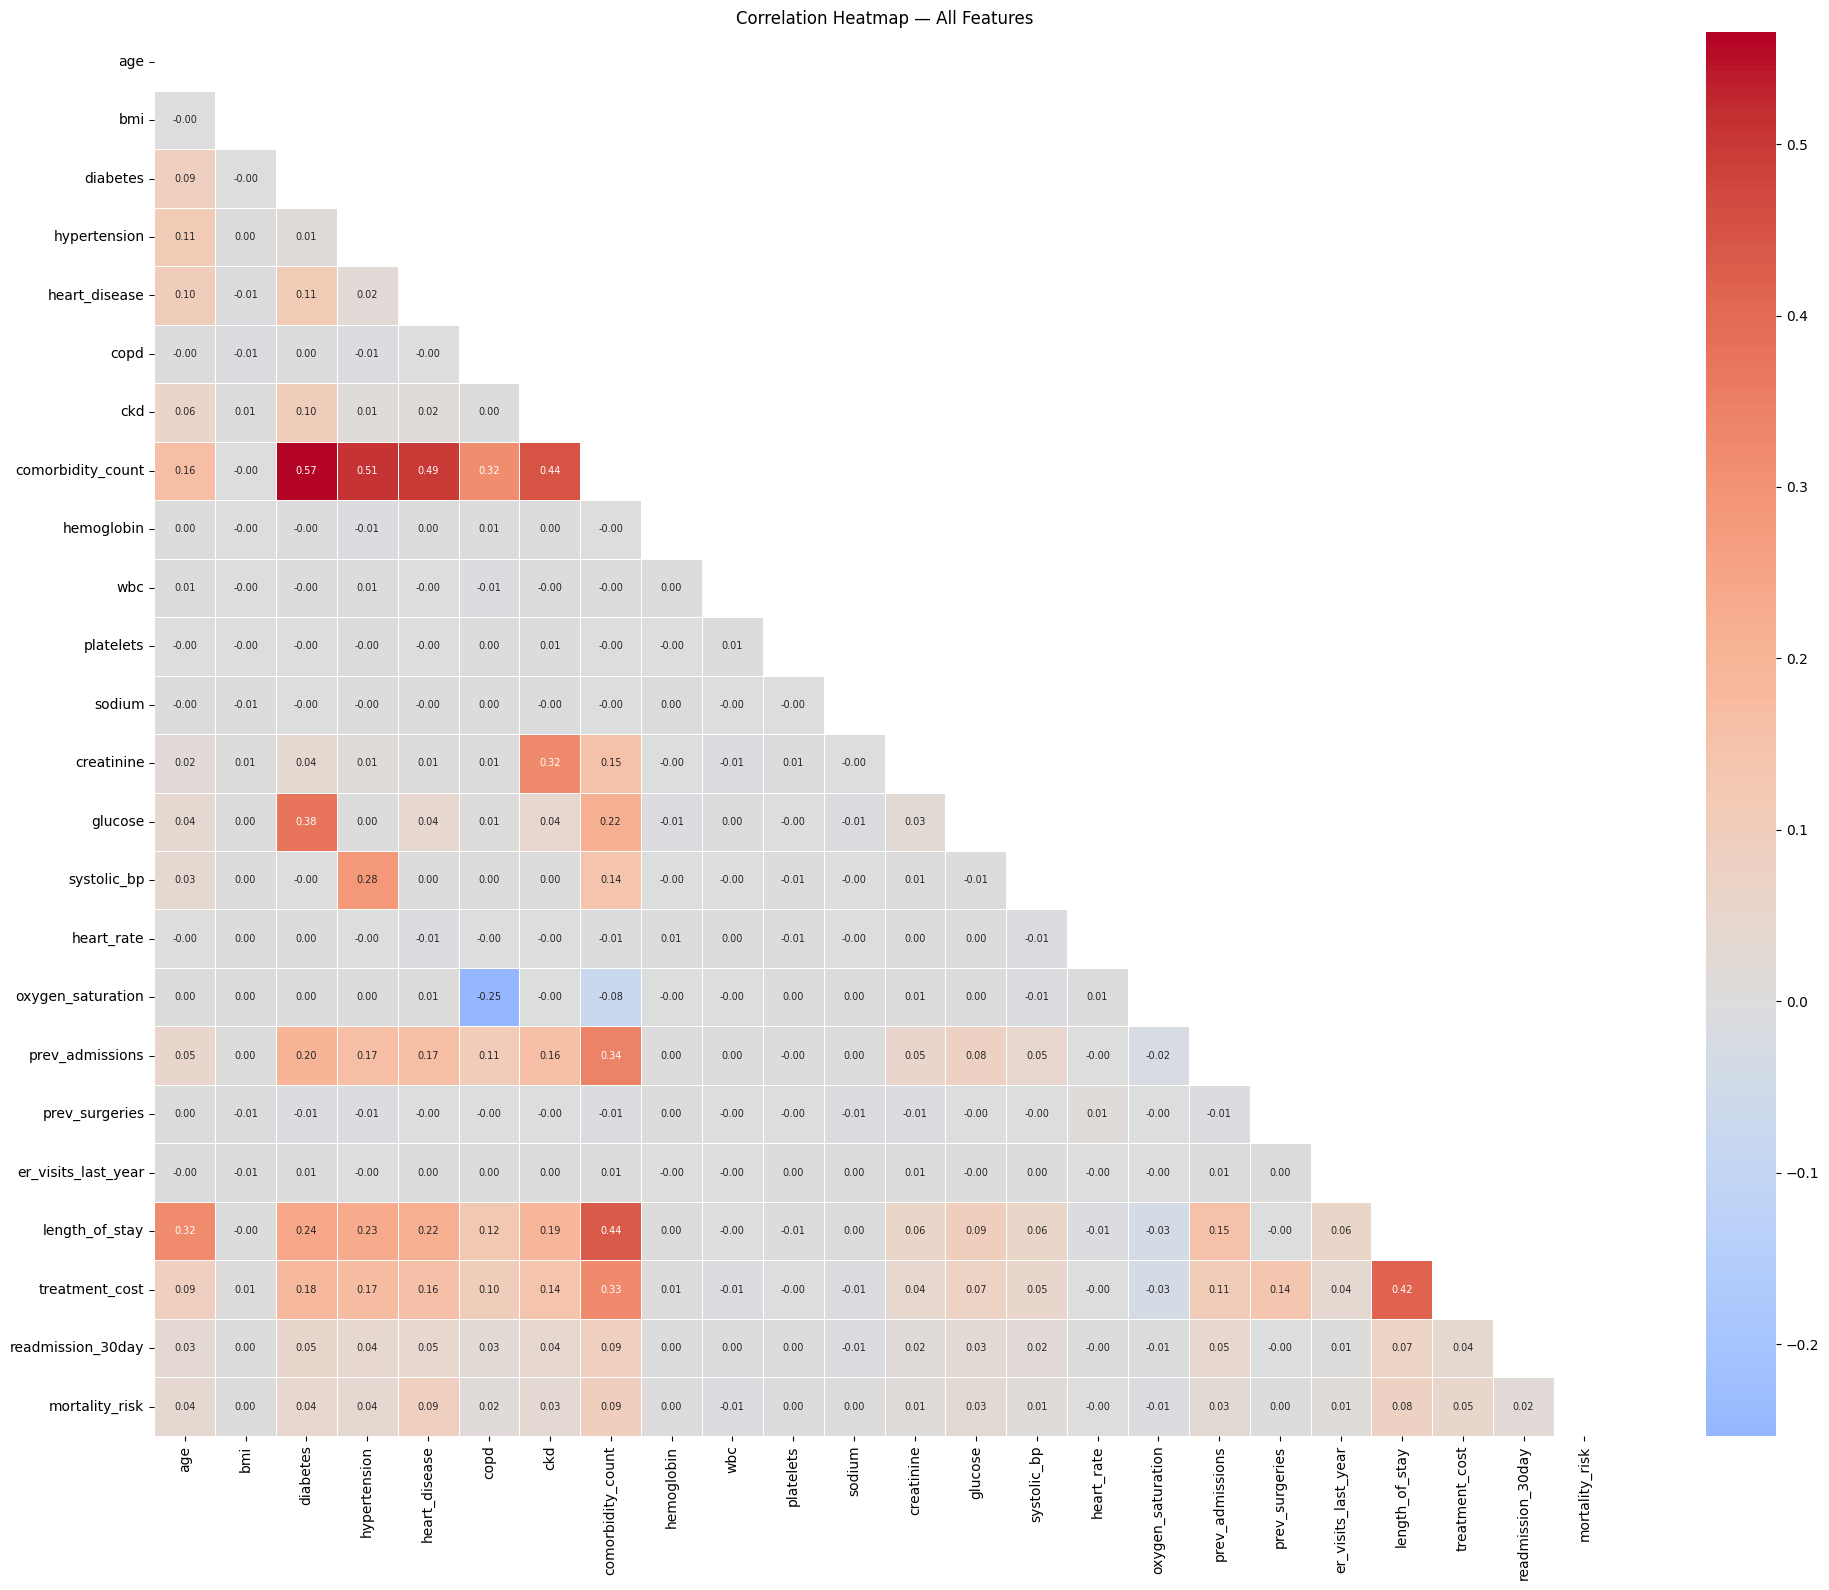

In [12]:
plt.figure(figsize=(20, 16))
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, mask=mask, linewidths=0.4, annot_kws={'size':7})
plt.title('Correlation Heatmap — All Features')
plt.tight_layout()
plt.show()

In [13]:
# fixing null values
dp=df.isna().sum().sort_values(ascending=False)[:11]
dp

alcohol_use          27455
bmi                   5958
insurance_type        4968
prev_surgeries        4932
glucose               4464
sodium                4119
creatinine            3549
platelets             3025
oxygen_saturation     2514
hemoglobin            2430
wbc                   2062
dtype: int64

In [14]:
dp.values/len(df)

array([0.5491 , 0.11916, 0.09936, 0.09864, 0.08928, 0.08238, 0.07098,
       0.0605 , 0.05028, 0.0486 , 0.04124])

Observations:

As the alcohol_use percentage is having more than 50% null values .so it's no meaning to impute them , it is more often guessing values, that is more of fabrication of feature
consider dropping feature

In [15]:
df.drop(['alcohol_use'],axis=1,inplace=True)

In [16]:
#bmi can imputed through median
# insureance can be private as it more frequently reqpest
# prev_sugreies can be zero , as the null values are quite low
# impute category with mode for glucose is it correct

df['glucose'].value_counts()

glucose
50.0     1923
80.0      817
113.9      70
104.5      67
110.2      65
         ... 
268.7       1
206.4       1
220.9       1
204.8       1
222.3       1
Name: count, Length: 1763, dtype: int64

In [17]:
for col in df.columns:
    if df[col].isna().sum()>0:
        print(df[col].value_counts(normalize=True).round(3))
        print(f"missing values in {col} are {df.isna().sum()[col]/len(df)}")
        print(f"\n")

bmi
14.0    0.020
27.4    0.007
25.5    0.007
28.4    0.007
27.2    0.007
        ...  
49.2    0.000
51.0    0.000
47.6    0.000
47.9    0.000
48.6    0.000
Name: proportion, Length: 360, dtype: float64
missing values in bmi are 0.11916


insurance_type
Private       0.445
Government    0.388
Self-Pay      0.167
Name: proportion, dtype: float64
missing values in insurance_type are 0.09936


hemoglobin
12.8    0.018
13.2    0.018
13.1    0.018
13.0    0.018
13.4    0.018
        ...  
5.0     0.000
5.3     0.000
4.7     0.000
5.1     0.000
4.6     0.000
Name: proportion, Length: 156, dtype: float64
missing values in hemoglobin are 0.0486


wbc
2.000000     0.024
7.900000     0.014
6.900000     0.014
7.700000     0.014
7.600000     0.014
             ...  
37.866512    0.000
43.783347    0.000
43.660264    0.000
46.313124    0.000
28.938334    0.000
Name: proportion, Length: 1587, dtype: float64
missing values in wbc are 0.04124


platelets
50.0     0.007
254.0    0.006
245.0    0.005
2

In [18]:
continous=['bmi','hemoglobin','wbc','platelets','sodium','creatinine','glucose','oxygen_saturation']
category=['insurance_type','prev_surgeries']
for col in continous:
    df[col]=df[col].fillna(df[col].median())
for col in category:
    df[col]=df[col].fillna(df[col].mode()[0])

observation of null's:
1) bmi, hemoglobin, wbc, platelets, sodium, creatinine, glucose, 
  oxygen_saturation- are continuous value with distribution skewness and outlier influence - so impute with median
2) insurance_type - is categorical , Private is dominant class , so mode impute
3) prev_surgeries- mode impute , even though it is count variable but 0 is more dominant

In [19]:
for col in numerical:
    q1=df[col].quantile(0.25)
    q3=df[col].quantile(0.75)
    IQR=q3-q1
    lower_bound=q1-IQR*1.5
    upper_bound=q3+1.5*IQR
    outliers=df[(df[col]<lower_bound) | (df[col]>upper_bound)]
    print(f" sum of outliers of {col} are {len(outliers)}")
    

 sum of outliers of age are 0
 sum of outliers of bmi are 516
 sum of outliers of diabetes are 0
 sum of outliers of hypertension are 0
 sum of outliers of heart_disease are 11019
 sum of outliers of copd are 5379
 sum of outliers of ckd are 8274
 sum of outliers of comorbidity_count are 0
 sum of outliers of hemoglobin are 471
 sum of outliers of wbc are 1608
 sum of outliers of platelets are 299
 sum of outliers of sodium are 713
 sum of outliers of creatinine are 446
 sum of outliers of glucose are 400
 sum of outliers of systolic_bp are 114
 sum of outliers of heart_rate are 120
 sum of outliers of oxygen_saturation are 310
 sum of outliers of prev_admissions are 245
 sum of outliers of prev_surgeries are 2152
 sum of outliers of er_visits_last_year are 2037
 sum of outliers of length_of_stay are 953
 sum of outliers of treatment_cost are 1341
 sum of outliers of readmission_30day are 7493
 sum of outliers of mortality_risk are 2850


In [20]:
outlier_cols = ['bmi', 'hemoglobin', 'wbc', 'platelets', 
                'sodium', 'creatinine', 'glucose', 
                'oxygen_saturation', 'systolic_bp', 
                'heart_rate', 'treatment_cost', 'length_of_stay']
for col in outlier_cols:
    q1=df[col].quantile(0.25)
    q3=df[col].quantile(0.75)
    IQR=q3-q1
    lower_bound=q1-IQR*1.5
    upper_bound=q3+1.5*IQR
    outliers=df[(df[col]<lower_bound) | (df[col]>upper_bound)]
    print(f" sum of outliers of {col} are {len(outliers)}")
    

 sum of outliers of bmi are 516
 sum of outliers of hemoglobin are 471
 sum of outliers of wbc are 1608
 sum of outliers of platelets are 299
 sum of outliers of sodium are 713
 sum of outliers of creatinine are 446
 sum of outliers of glucose are 400
 sum of outliers of oxygen_saturation are 310
 sum of outliers of systolic_bp are 114
 sum of outliers of heart_rate are 120
 sum of outliers of treatment_cost are 1341
 sum of outliers of length_of_stay are 953


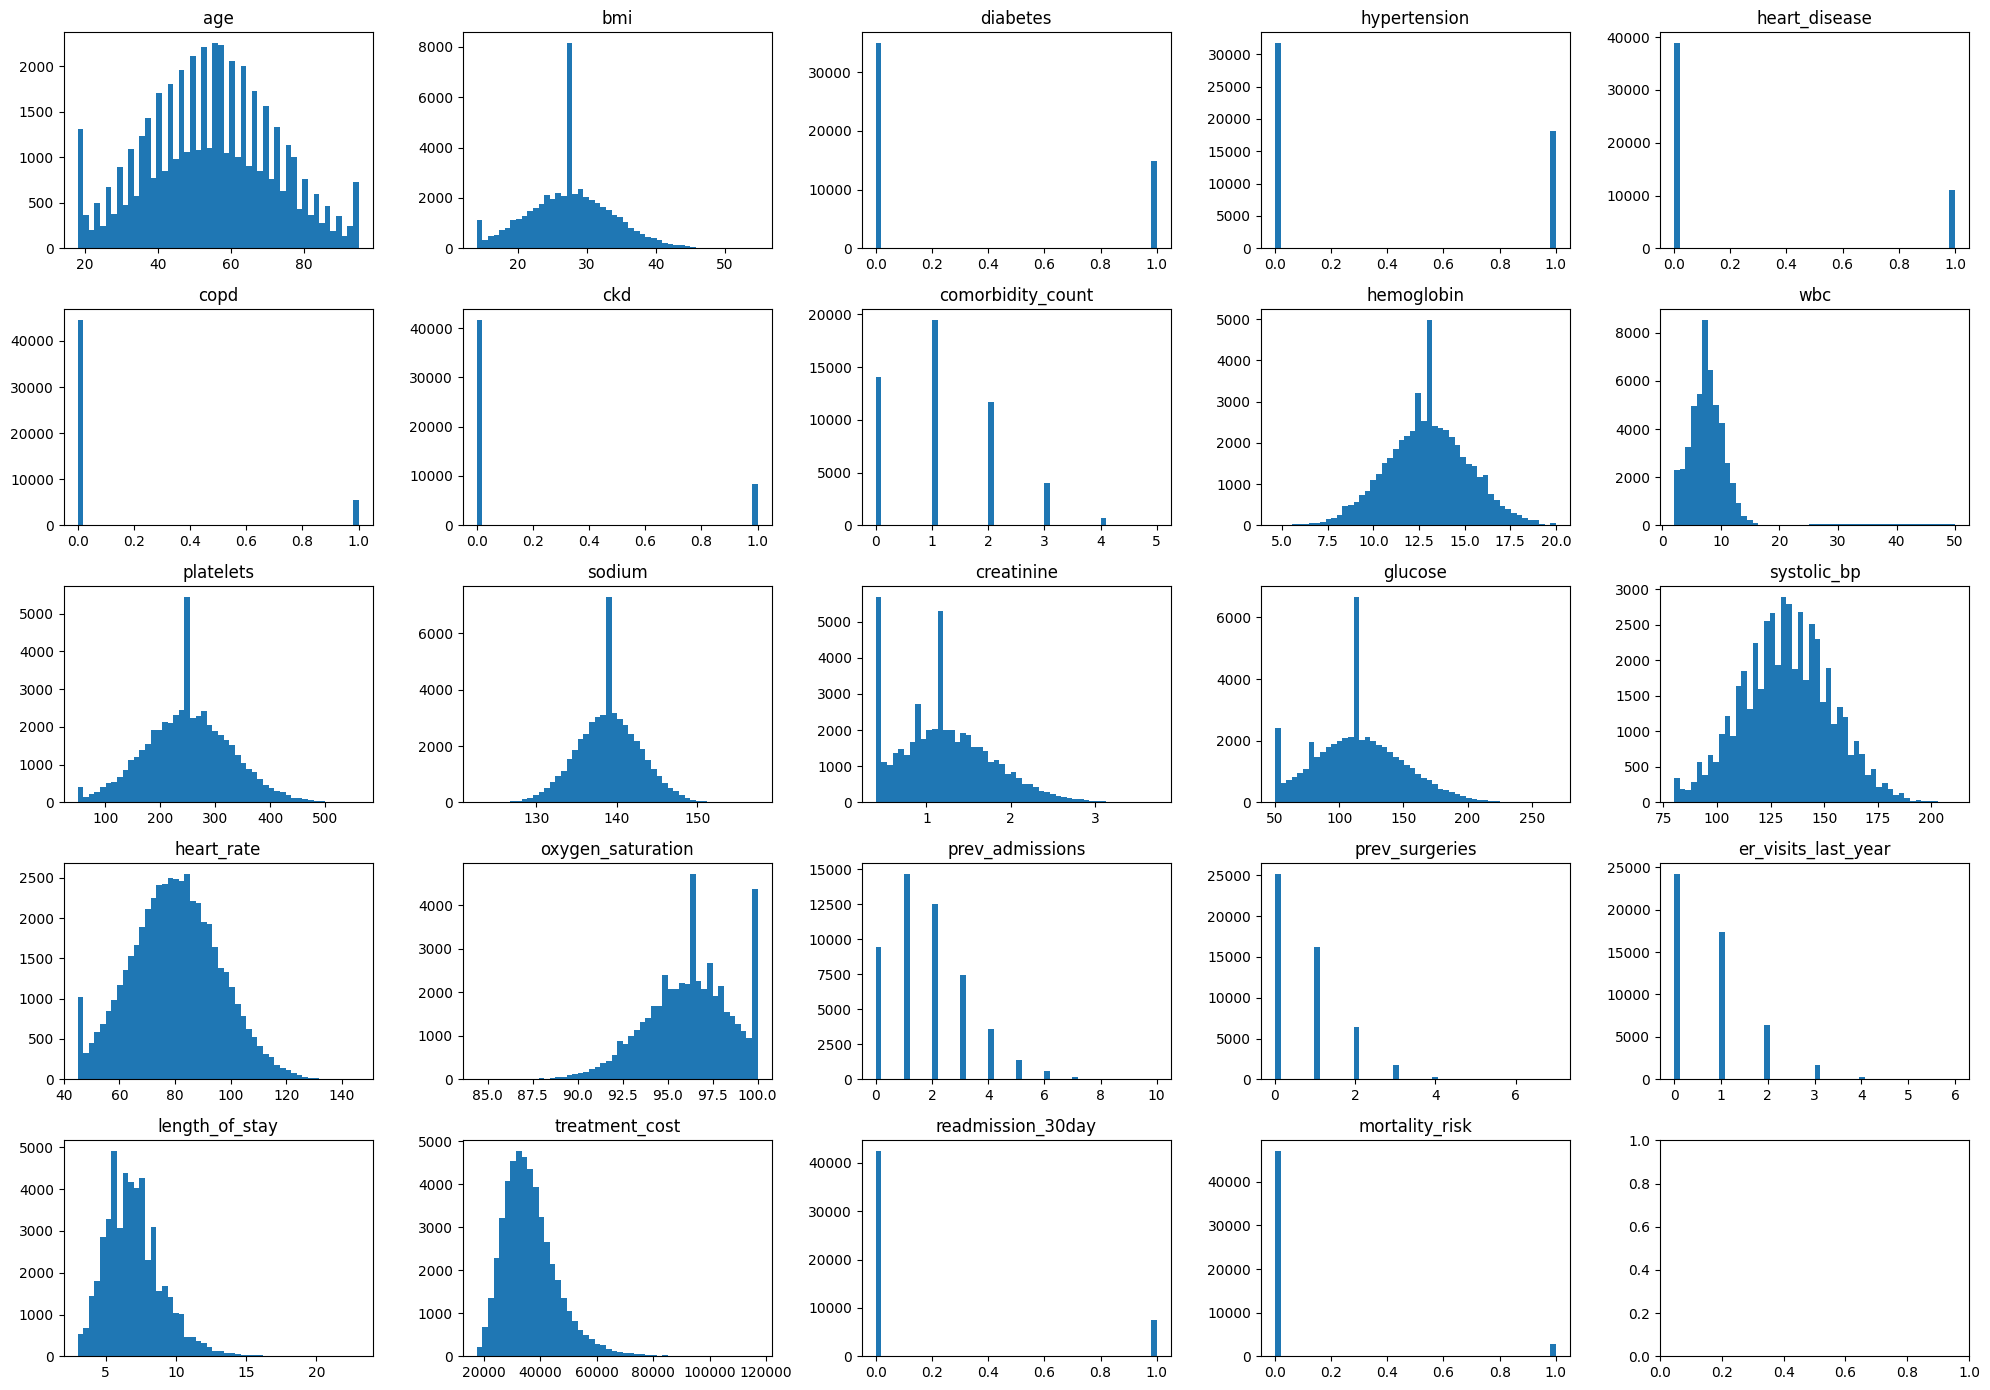

In [21]:
fig, axes = plt.subplots(5, 5, figsize=(20, 14))
axes = axes.flatten()
for i, col in enumerate(numerical):
    axes[i].hist(df[col].dropna(), bins=50)
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

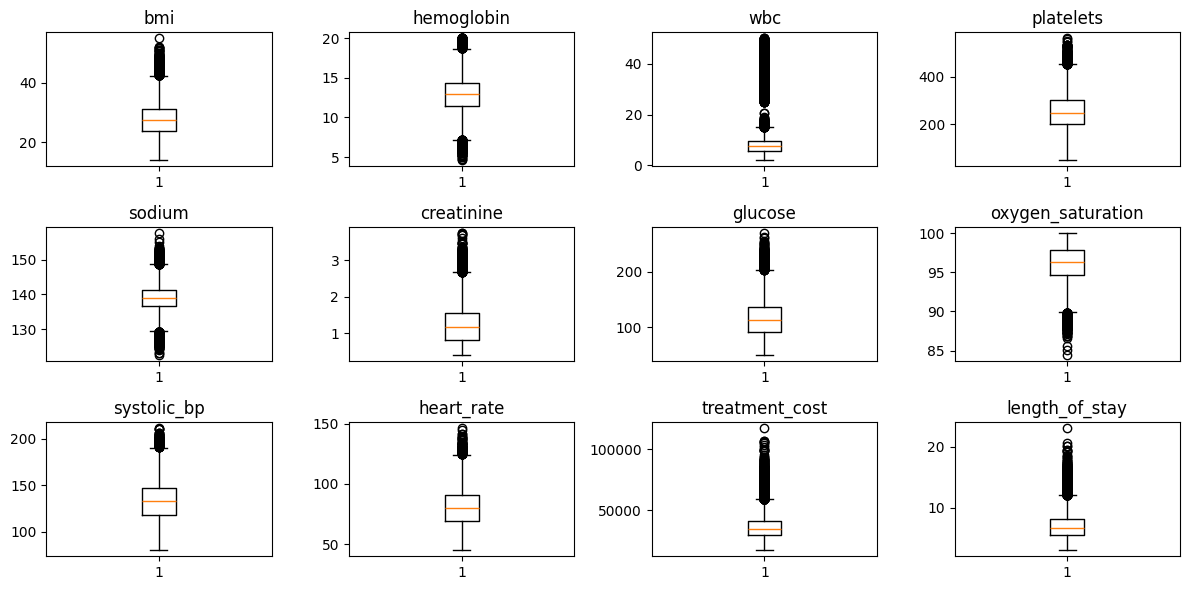

In [22]:
fig,axes=plt.subplots(3,4,figsize=(12,6))
axes=axes.flatten()
for i, col in enumerate(outlier_cols):
    axes[i].boxplot(df[col].dropna().values)
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

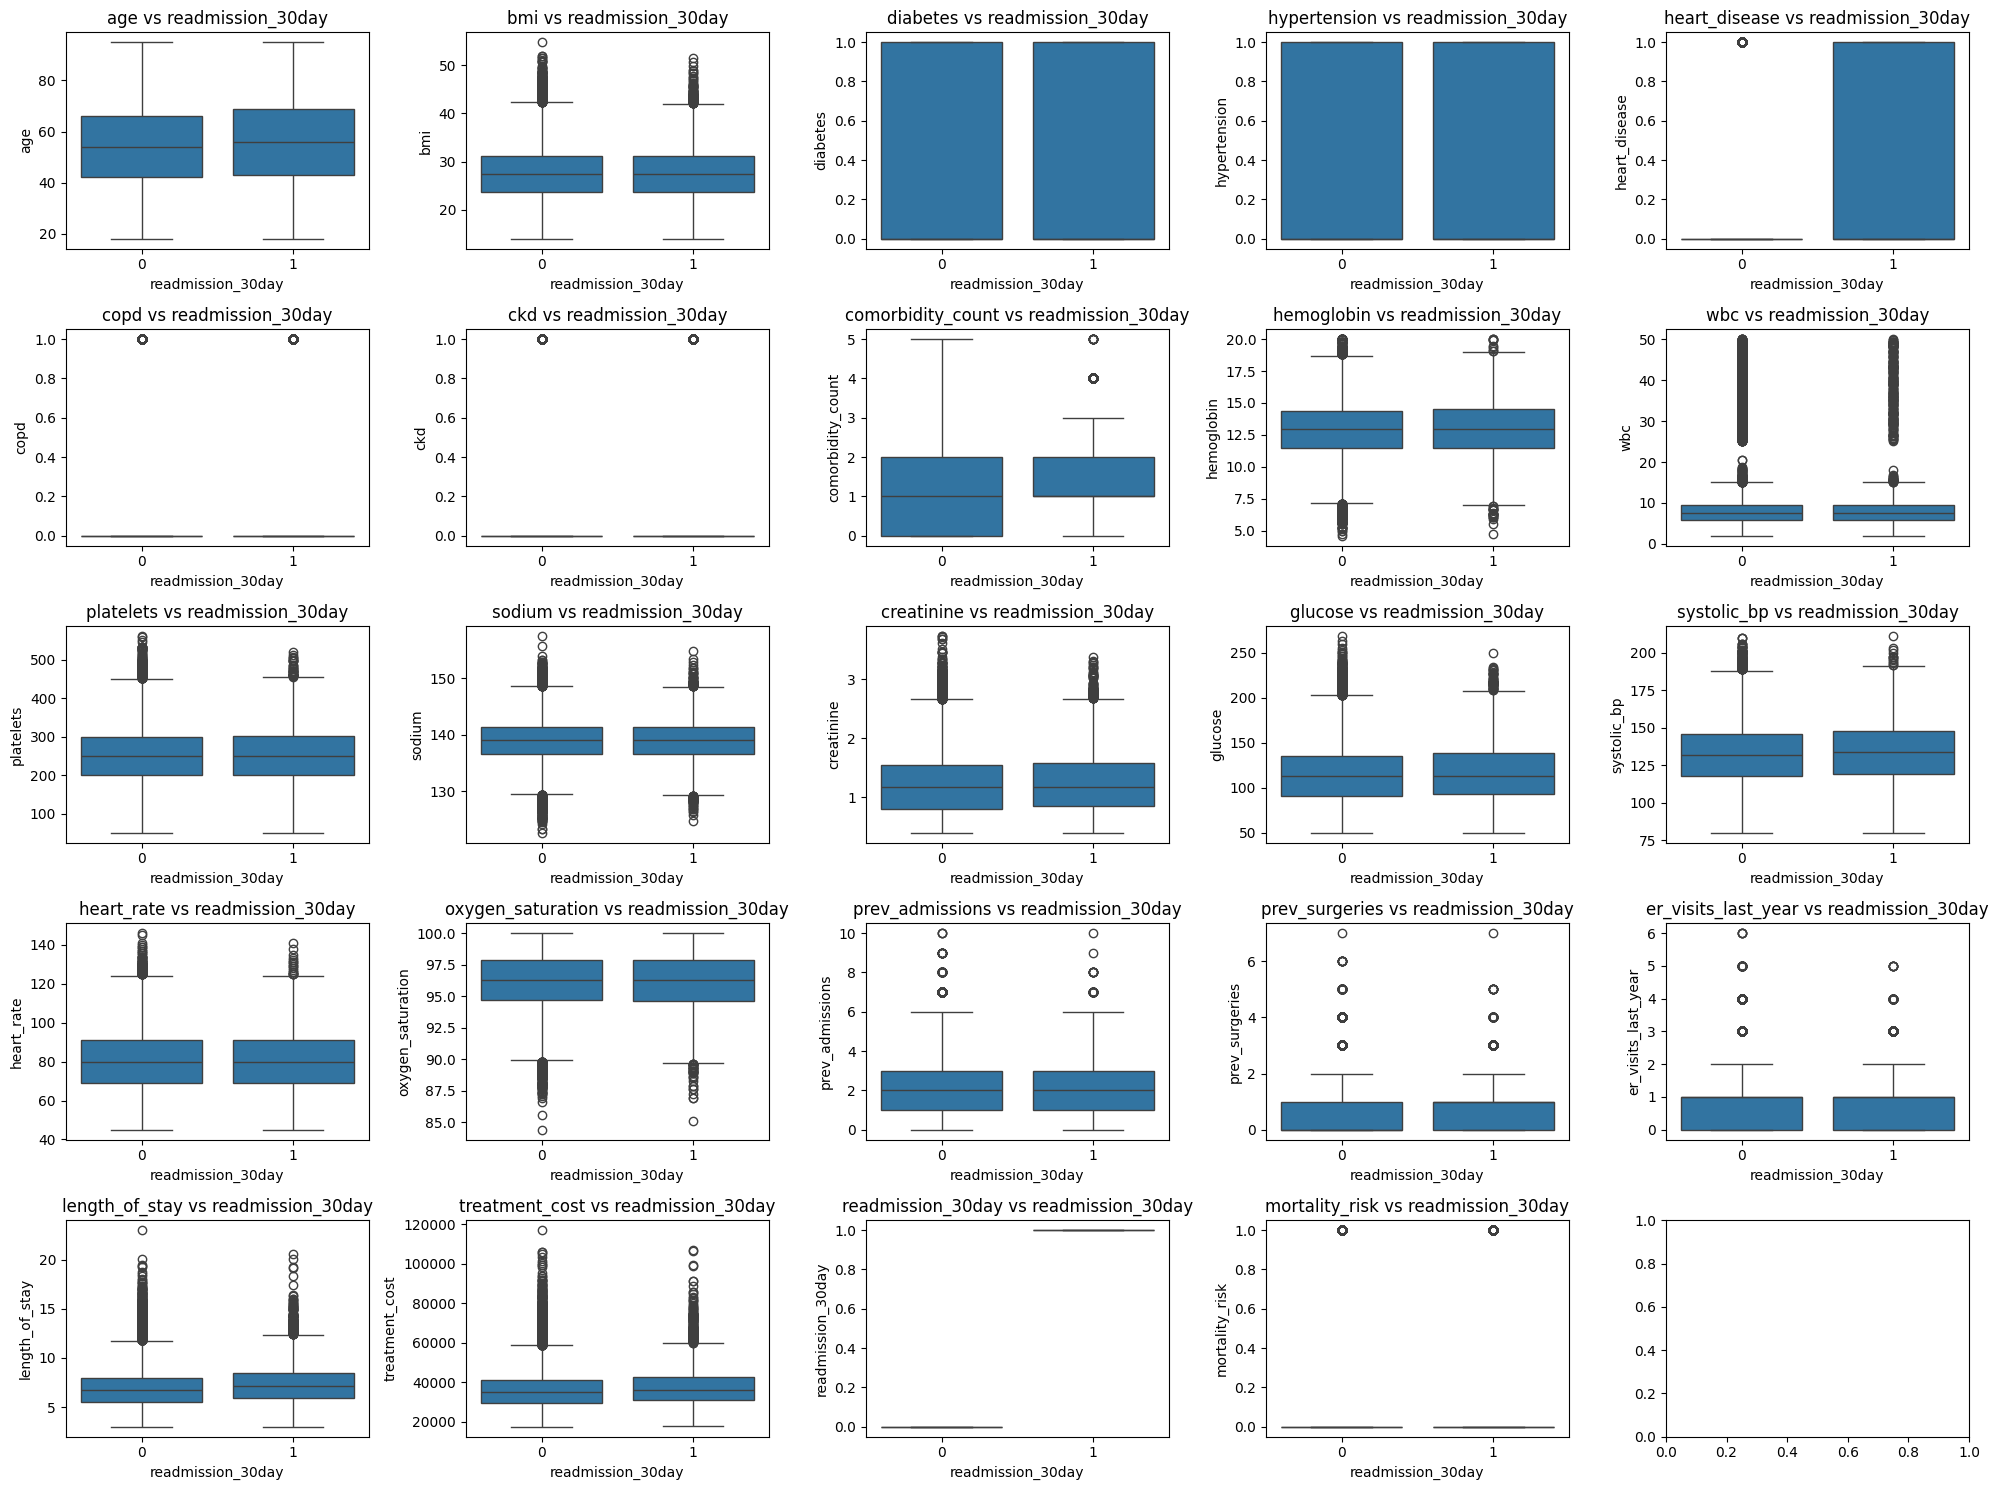

In [23]:
fig,axes=plt.subplots(5,5,figsize=(20,15))
axes=axes.flatten()
for i,col in enumerate(numerical):
    sns.boxplot(x='readmission_30day',y=col,data=df,ax=axes[i])
    axes[i].set_title(f"{col} vs readmission_30day")
plt.tight_layout()
plt.show()

No features really corelates with readmission , Kinda expect modest recall with good models also

In [ ]:
categorical.remove('alcohol_use') # patient id as well

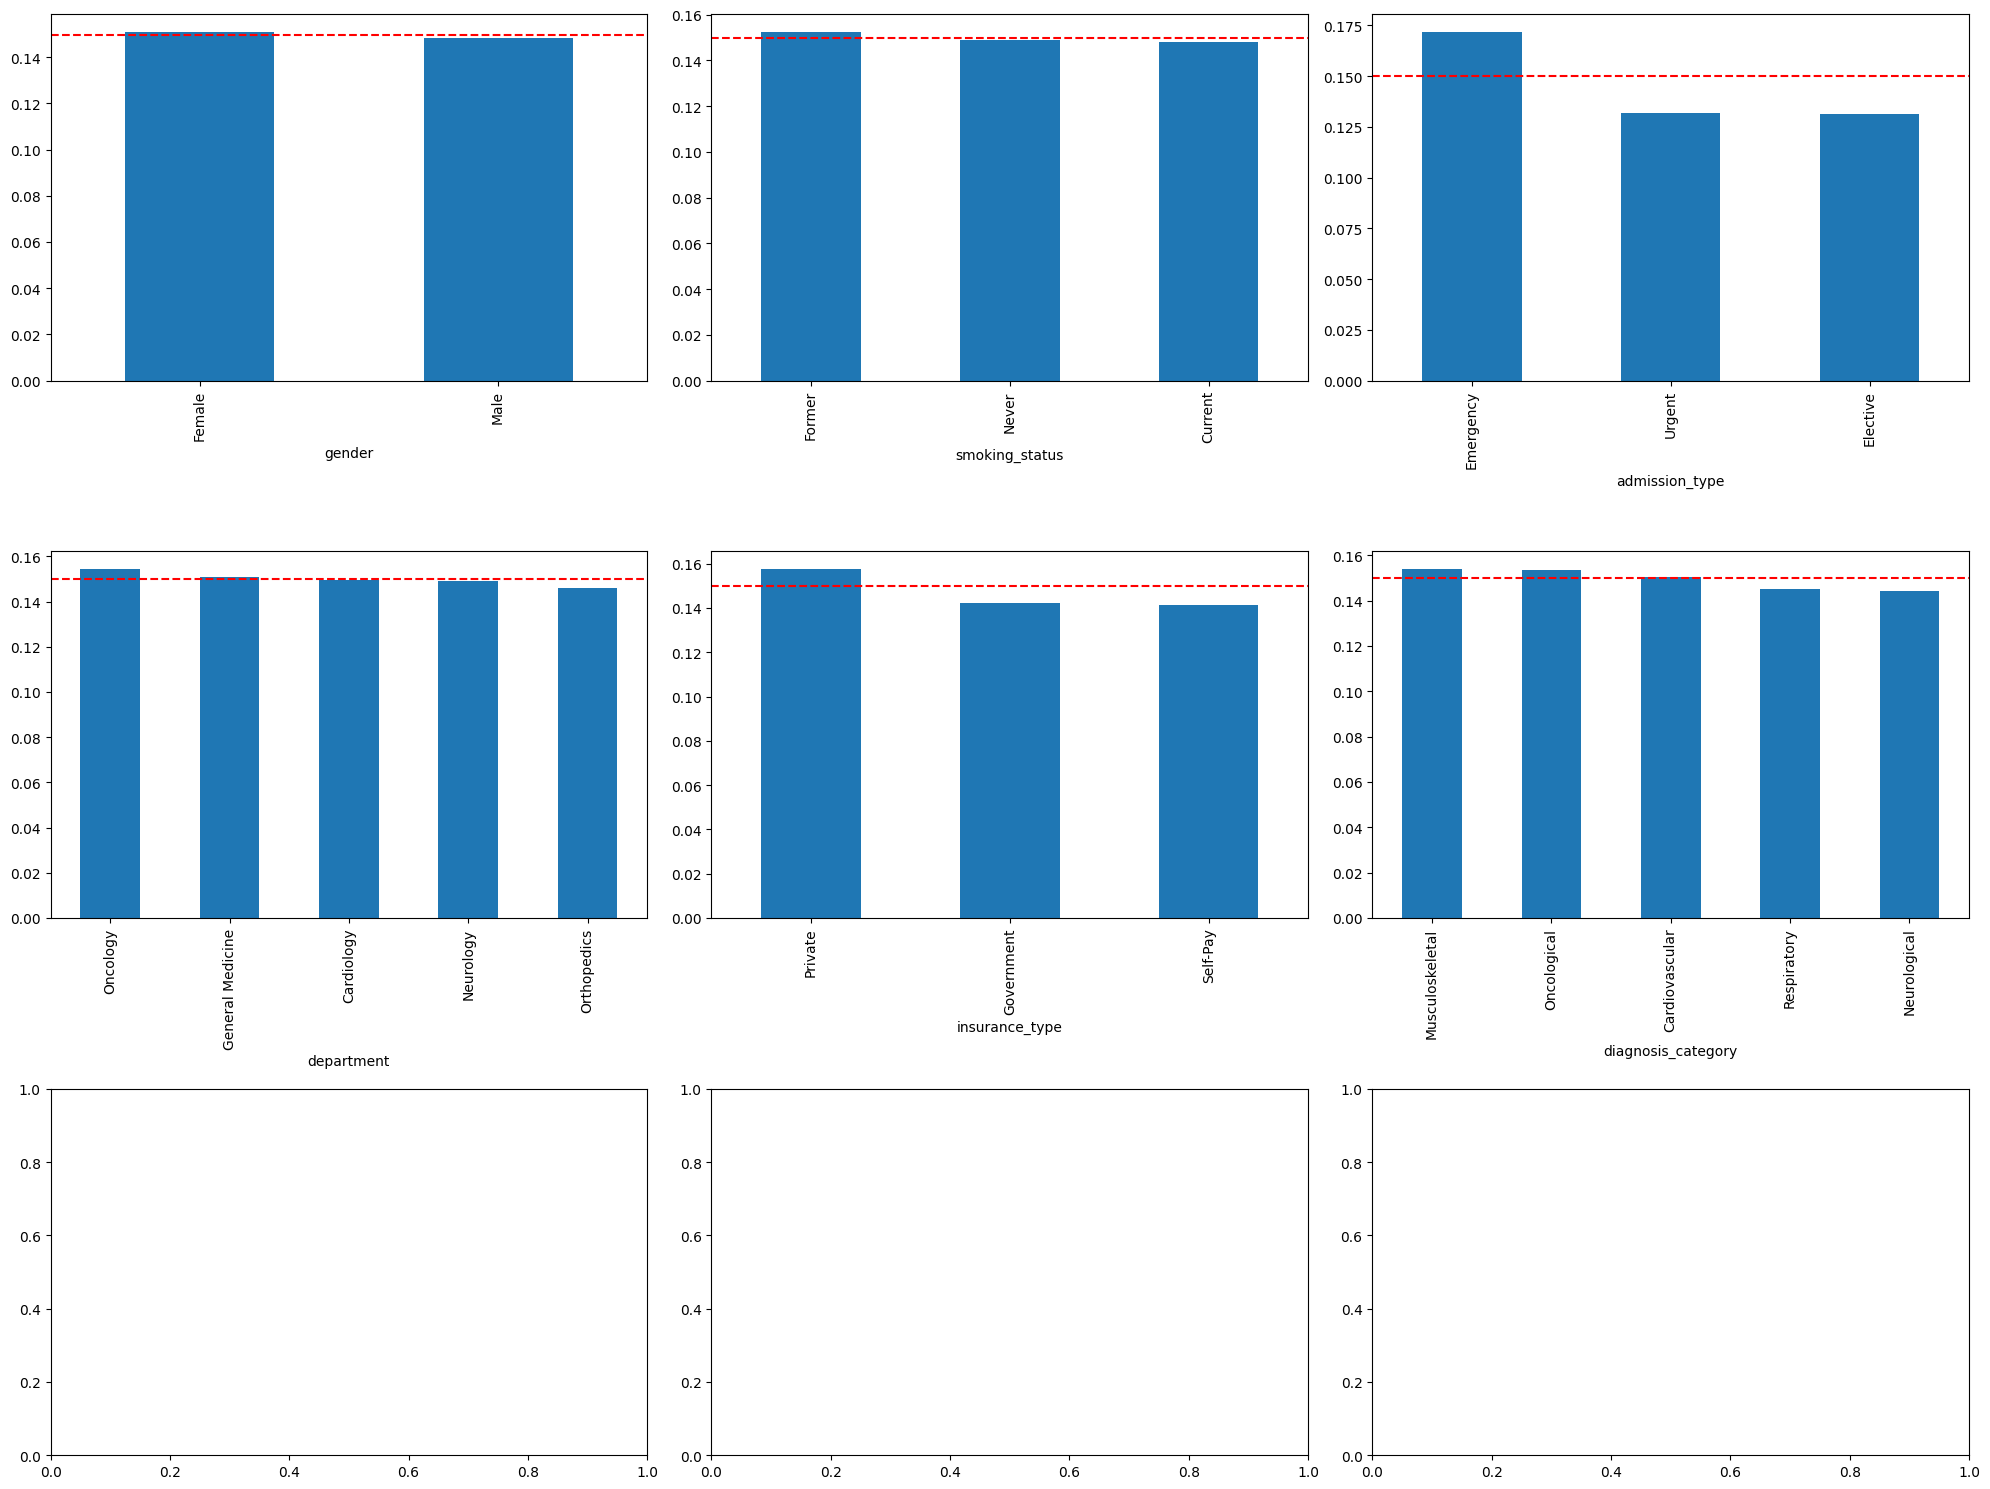

In [27]:
fig,axes=plt.subplots(3,3,figsize=(20,15))
axes=axes.flatten()
for i,col in enumerate(categorical):
    rate=df.groupby(col)['readmission_30day'].mean().sort_values(ascending=False)
    rate.plot(kind='bar',ax=axes[i])
    axes[i].axhline(y=df['readmission_30day'].mean(),color='red',linestyle='--')
plt.tight_layout()
plt.show()

observations on outliers:
1) when outliers exists for features , use winsorize  technique - to cap values at boundary 
and targets like length of stay and treat_ment cost as the distribution is right skewed , apply log transform to stabilize  

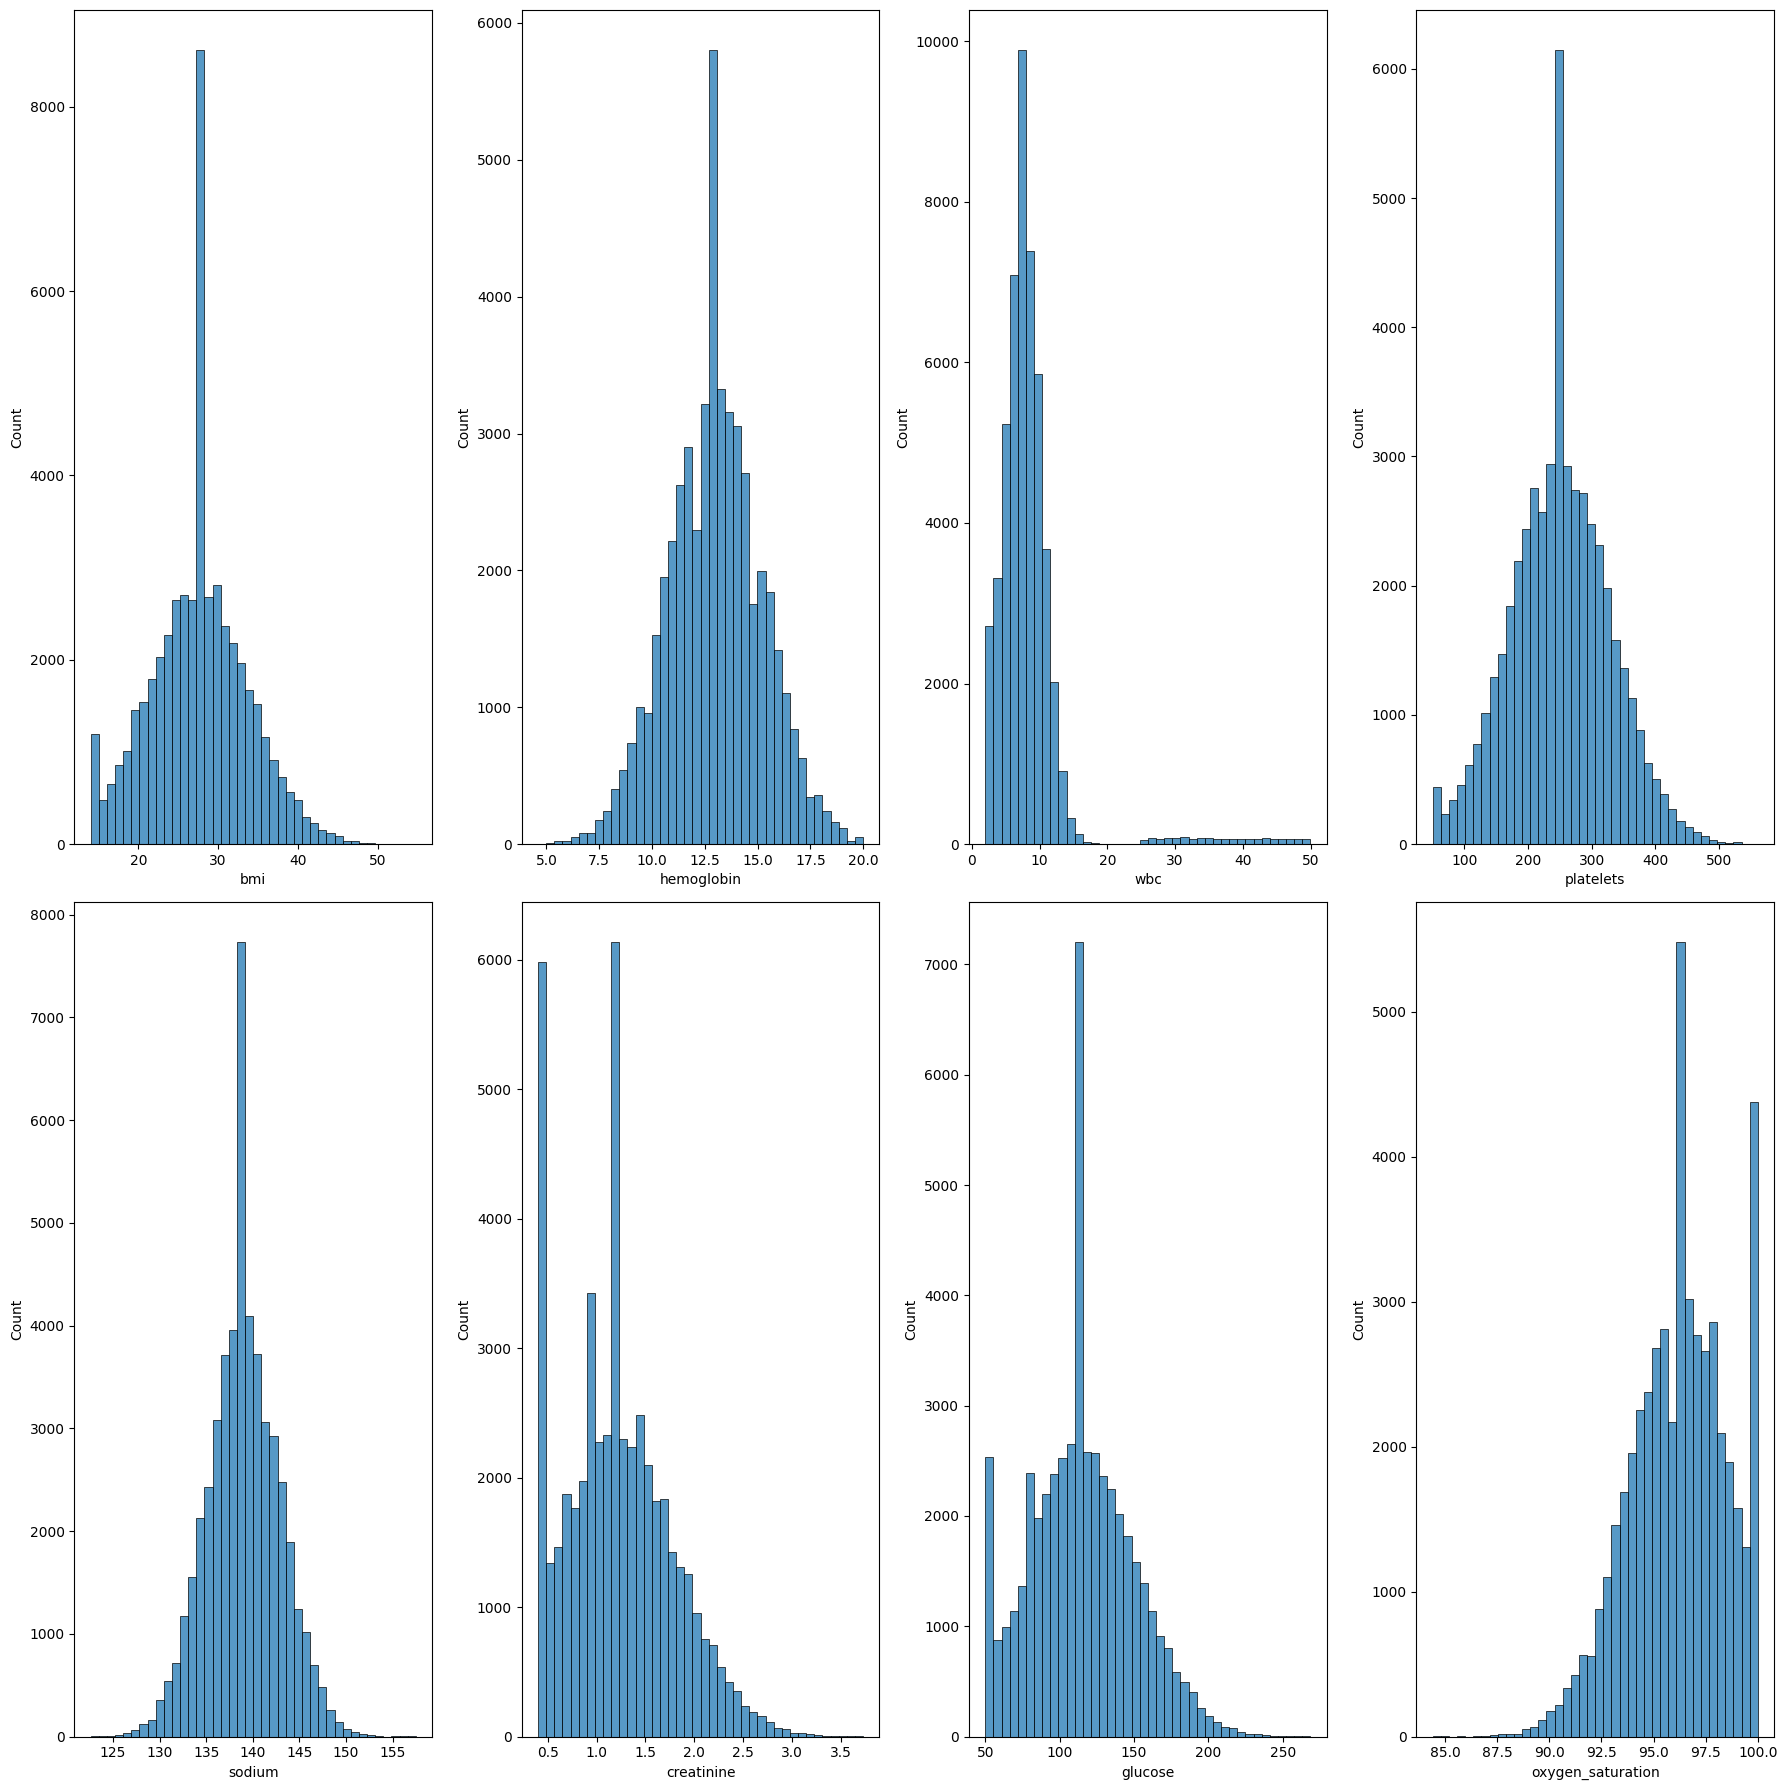

In [31]:
fig,axes=plt.subplots(2,4,figsize=(18,18))
axes=axes.flatten()
for i,col in enumerate(continous):
    sns.histplot(df[col],ax=axes[i],bins=40)
plt.tight_layout()
plt.show()


both creatinine and oxygen_saturation are might be floor and ceil values observations , because clincally and pratically for a contionus variable , they would n't be existing dominating concernation of data at a single value , Below is the evidence:

creatinine: 9.6% of rows (4,819) have exactly 0.40 — likely a floor 
  artifact. Continuous variables don't naturally spike at one value this heavily.
oxygen_saturation: 7.1% of rows (3,565) hit exactly 100.0 — ceiling 
  artifact.

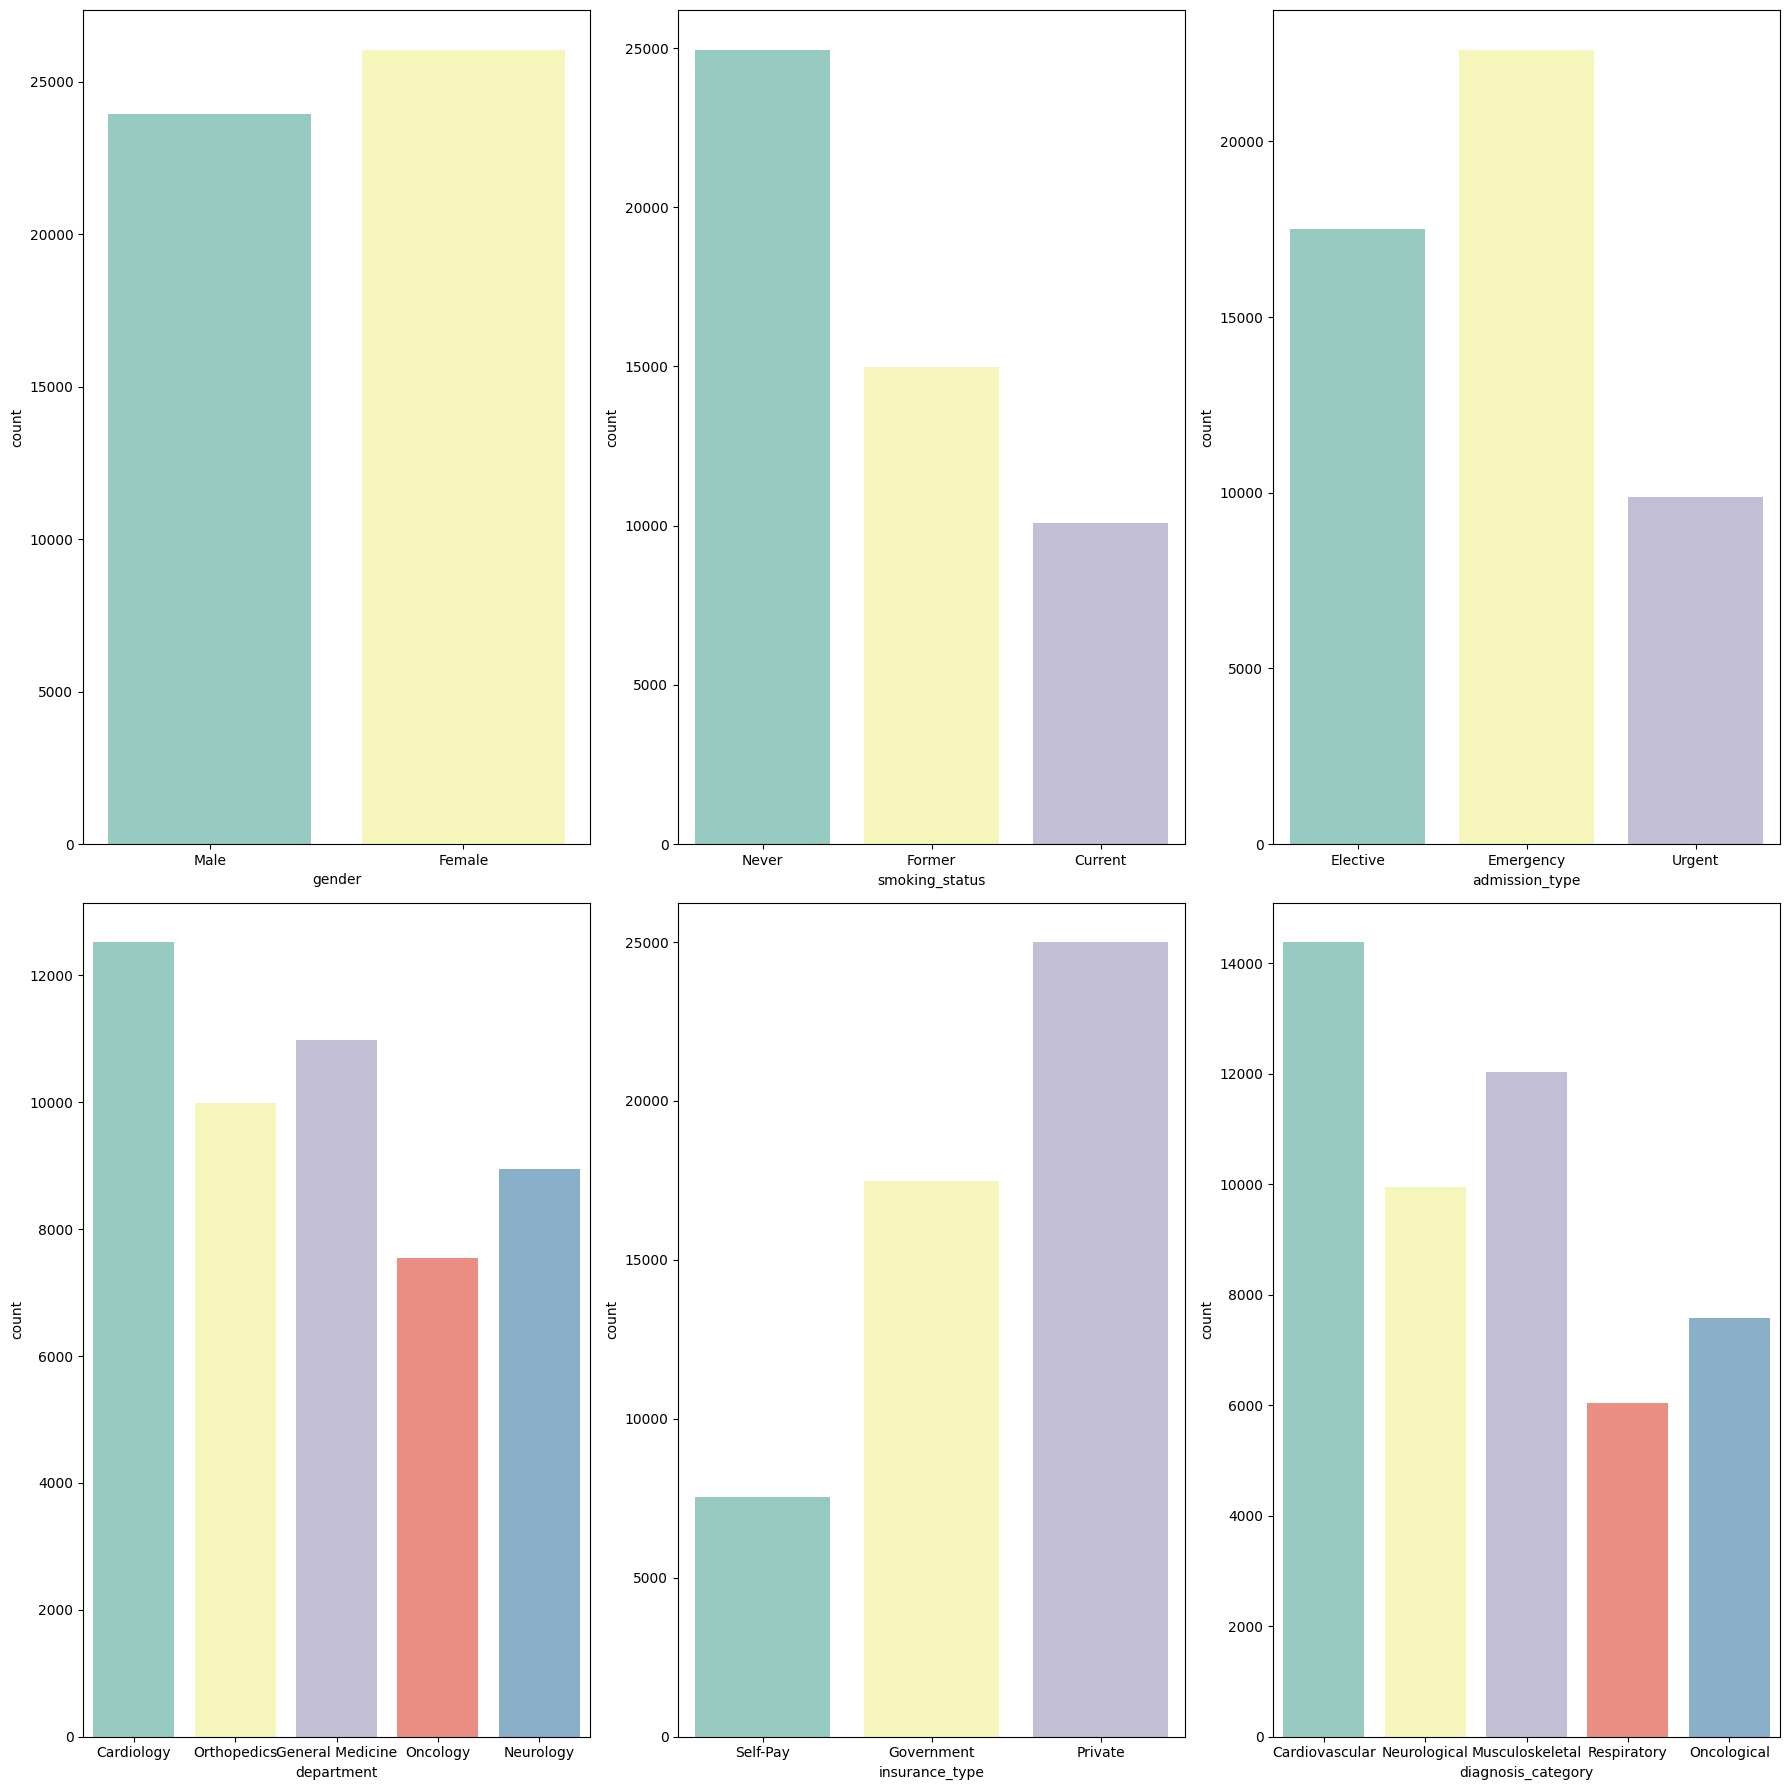

In [73]:
fig,axes=plt.subplots(2,3,figsize=(18,18))
axes=axes.flatten()
for i,col in enumerate(categorical):
    sns.countplot(data=df,x=col,ax=axes[i],palette='Set3',hue=col)
plt.tight_layout()
plt.show()


1) gender: slight female dominance, no action needed
2) smoking_status: Never smokers dominate — current smokers are minority, 
watch for underrepresentation in mortality models
3) admission_type: Emergency dominates — strong signal for mortality_risk 
  and length_of_stay, include in bivariate analysis against these targets
4) department/diagnosis_category: reasonably balanced, no action needed
5) insurance_type: Self-Pay severely underrepresented (~3,800 rows) — 
  may affect treatment_cost predictions for this group

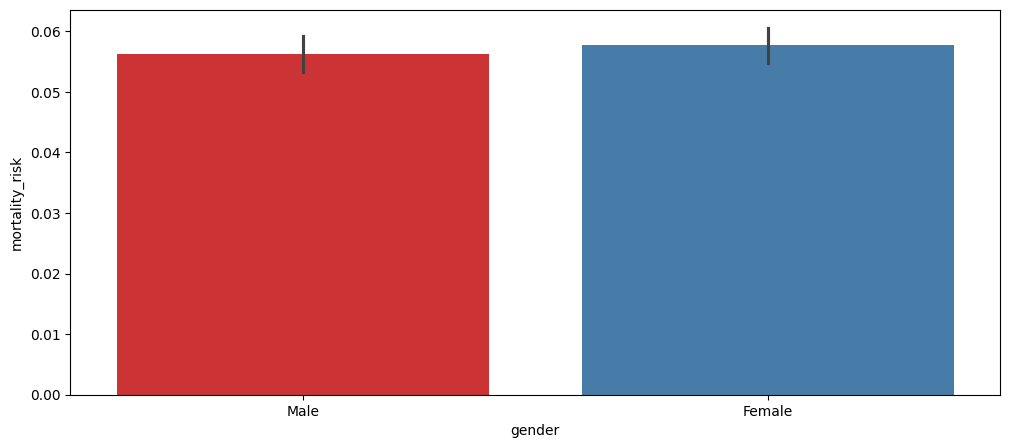

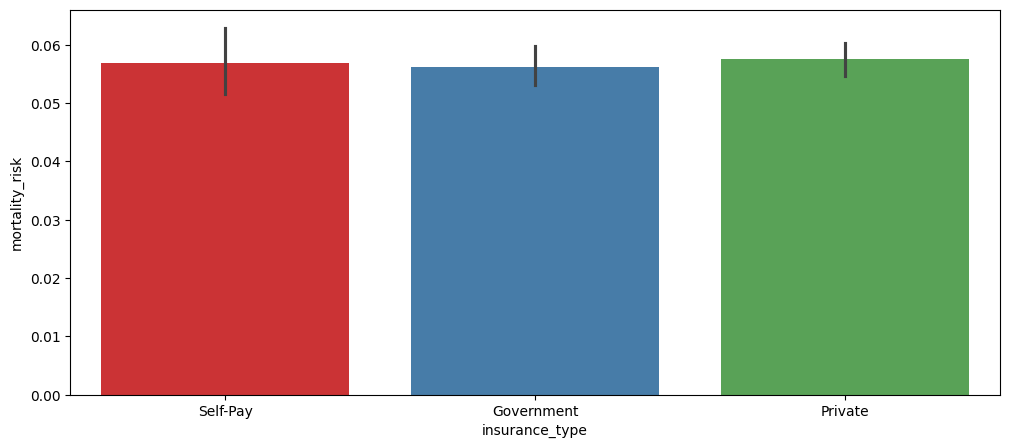

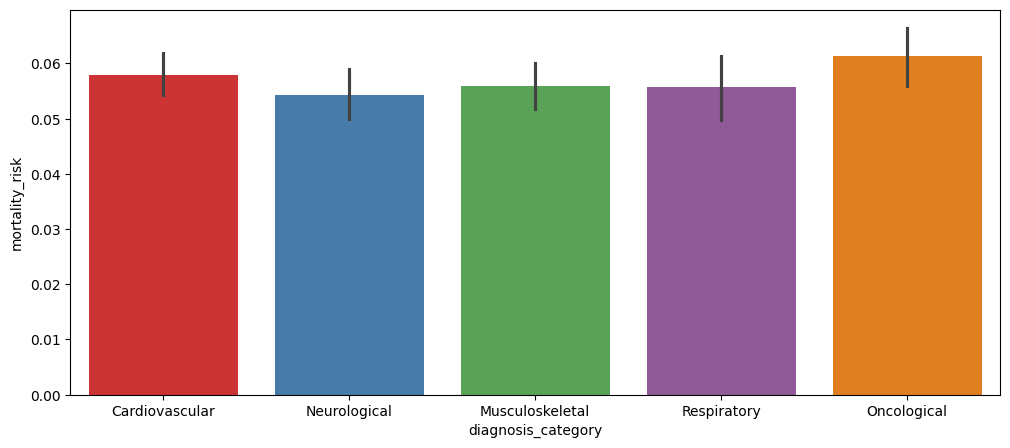

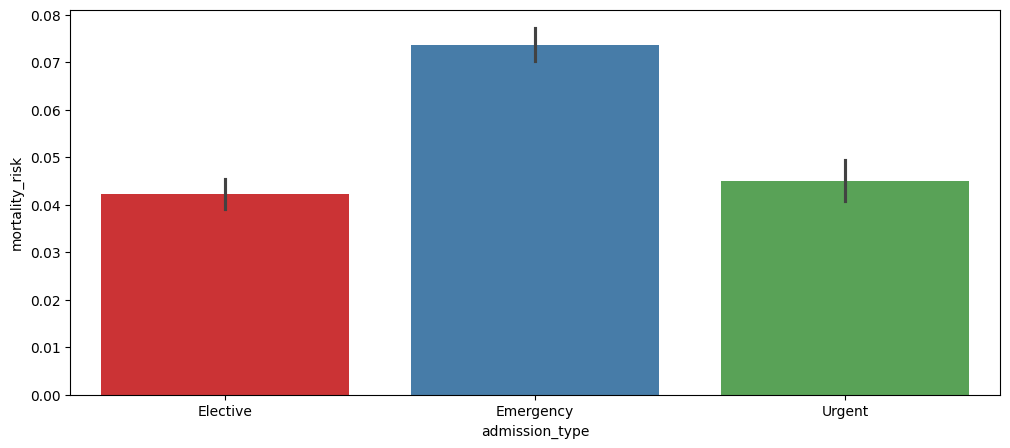

In [72]:
# target analysis on mortality risk vs categorical features
for col in ['gender','insurance_type','diagnosis_category','admission_type']:
    plt.figure(figsize=(12,5))
    sns.barplot(data=df,y='mortality_risk',x=col,palette='Set1',hue=col)
    plt.show()

1) admission_type: Emergency patients have 2x mortality rate (7.4% vs 4.2%) 
  — strong feature for mortality model
2)  diagnosis_category: Oncological slightly higher but differences small 
  — weak standalone signal for mortality
3) gender, insurance_type: no difference in mortality rate across categories 
  — likely low importance features, confirm via feature importance in modeling

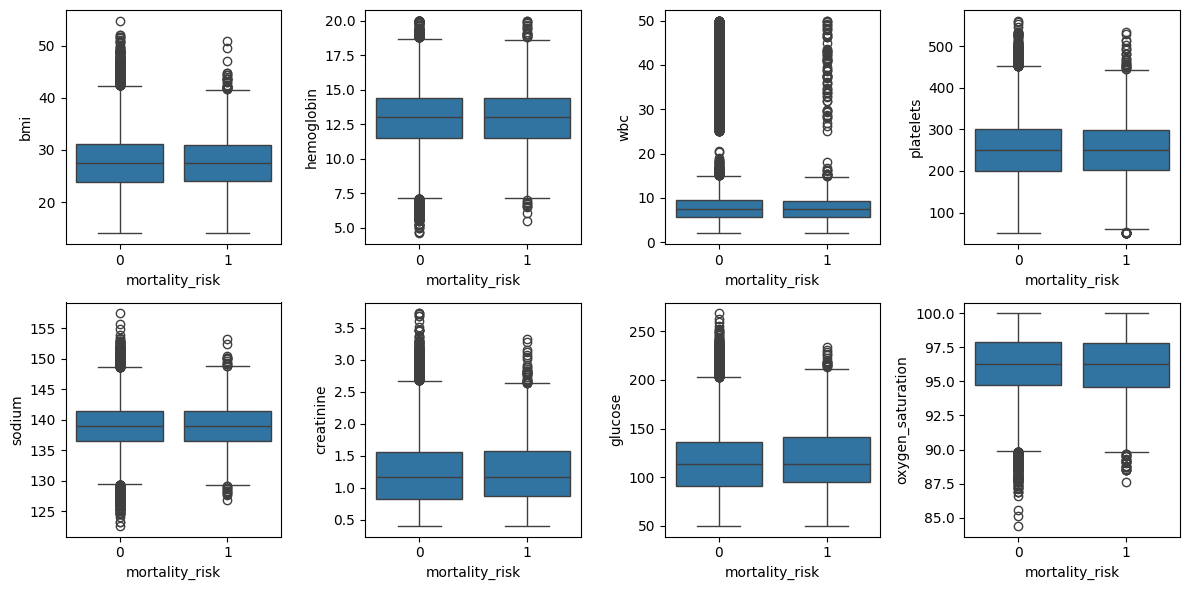

In [55]:
fig,axes=plt.subplots(2,4,figsize=(12,6))
axes=axes.flatten()
for i,col in enumerate(continous):
    sns.boxplot(data=df,x='mortality_risk',y=col,ax=axes[i])
plt.tight_layout()
plt.show()

1)  No continuous feature shows clear separation between mortality=0 and 1
2) Hemoglobin, creatinine, oxygen_saturation show minimal median difference
3) Mortality prediction will rely on feature combinations, not individual 
  features — tree models and SMOTE required

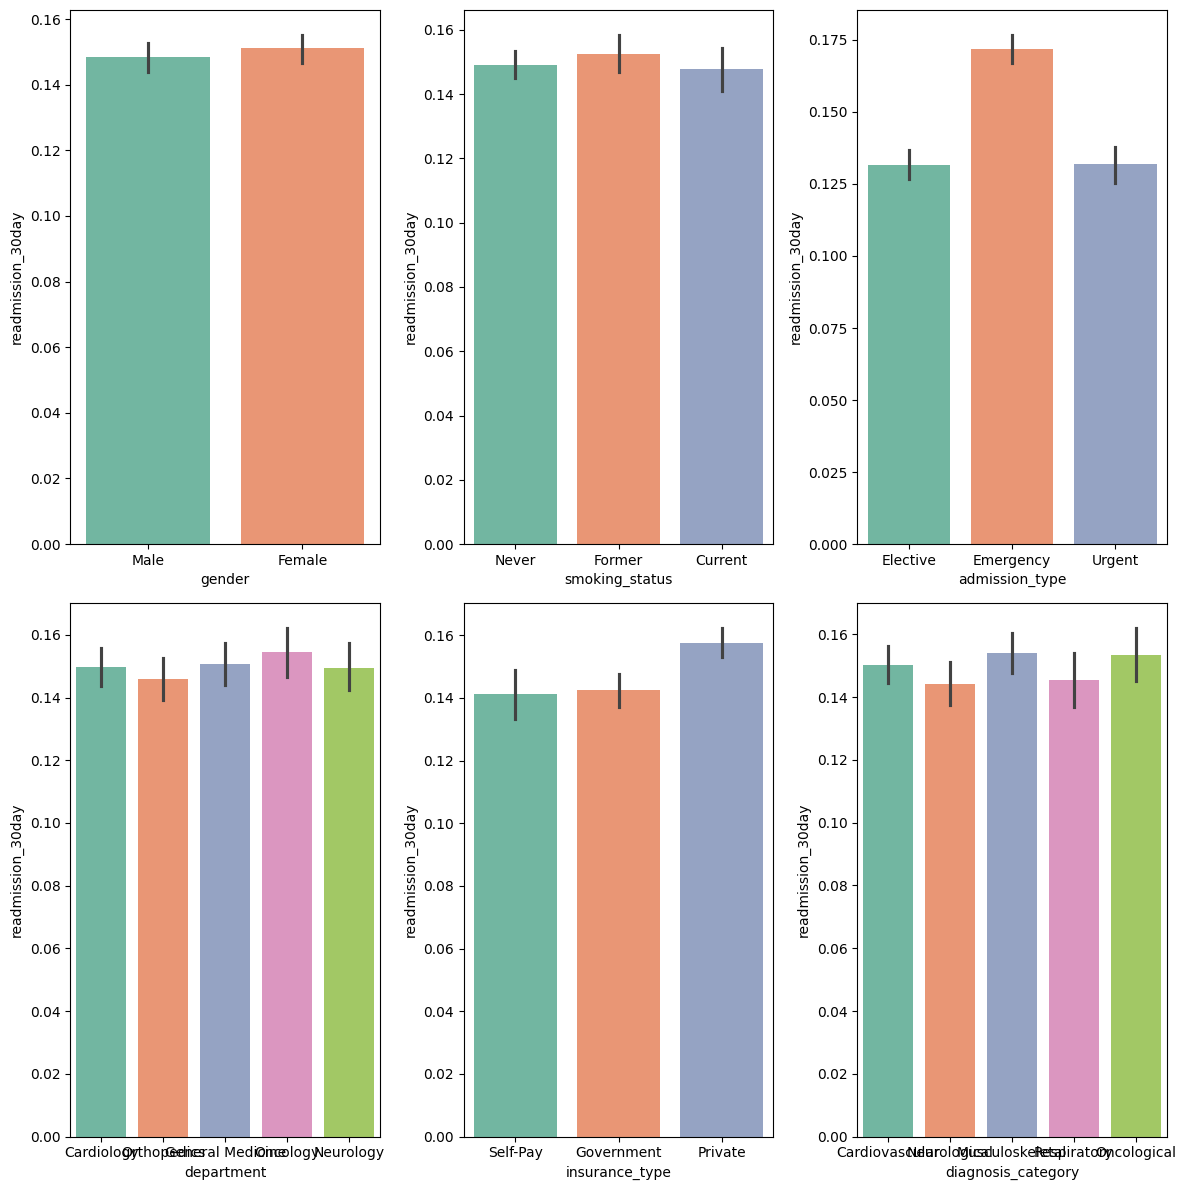

In [66]:
fig,axes=plt.subplots(2,3,figsize=(12,12))
axes=axes.flatten()
for i,col in enumerate(categorical):
    sns.barplot(data=df,x=col,y='readmission_30day',ax=axes[i],palette='Set2',hue=col)
plt.tight_layout()
plt.show()

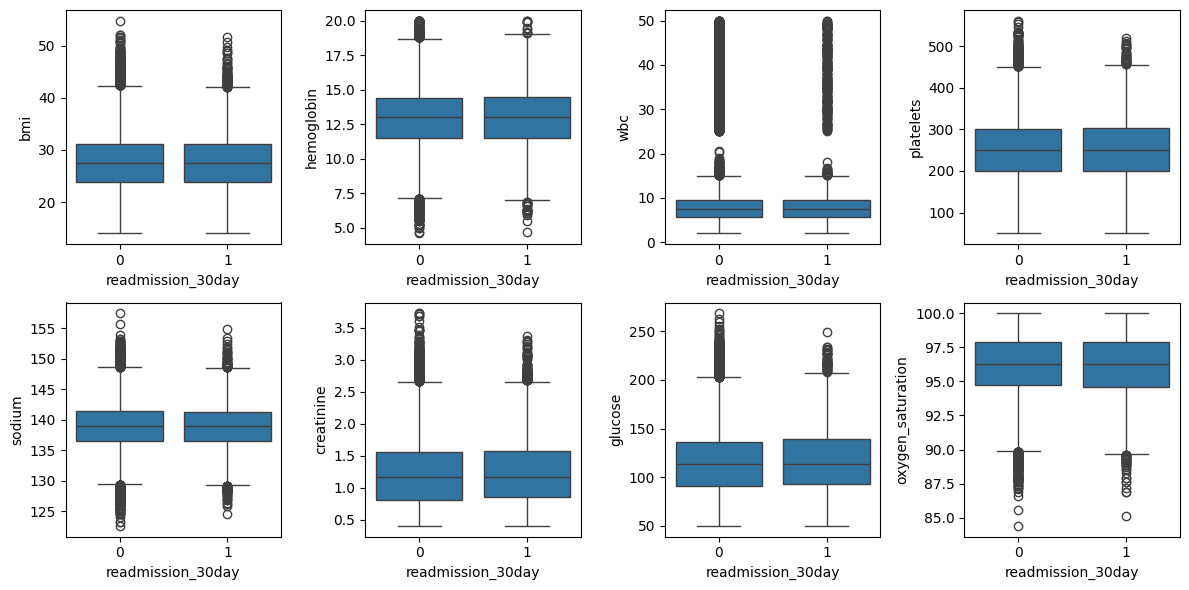

In [67]:
fig,axes=plt.subplots(2,4,figsize=(12,6))
axes=axes.flatten()
for i,col in enumerate(continous):
    sns.boxplot(data=df,x='readmission_30day',y=col,ax=axes[i])
plt.tight_layout()
plt.show()

1) Both mortality_risk and readmission_30day show no separation across 
  continuous features
2) admission_type is the strongest categorical signal for both targets (emergency value)
3) Both problems will rely on feature combinations — tree models essential